<h1 id="Lecture-3:-Lifecycle-artefacts">Lecture 3: Lifecycle artefacts</h1><p><strong>Case:</strong> FreshCart wants to reduce late deliveries.  A model is only one project artefact.  This notebook shows the evidence that should exist before, during, and after modelling.</p>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from ds301.paths import project_root
COURSE_ROOT = project_root()
TEAL, MINT, GOLD, CORAL, INK = "#005F73", "#0A9396", "#E9C46A", "#E76F51", "#1F2933"

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.dpi": 120, "axes.titleweight": "bold", "axes.spines.top": False, "axes.spines.right": False})
data = pd.read_csv(COURSE_ROOT / "data/freshcart_deliveries.csv")
data.head()

,delivery_id,distance_km,rain,riders_available,late,minutes_late
0,20001,13.20,0,4,0,0.0
1,20002,5.64,1,10,0,0.0
2,20003,5.20,0,6,0,0.0
3,20004,10.42,0,5,0,0.0
4,20005,8.85,0,9,1,9.6


<h2 id="Begin-with-the-records">Begin with the records</h2><p>One row records one FreshCart delivery. Read the available operational conditions and the late flag before summarising late rates. A lifecycle becomes useful when it preserves this link from a record to a decision artefact.</p>

In [2]:
data[["rain", "riders_available", "late"]].sample(12, random_state=301).sort_values(["rain", "riders_available"])

,rain,riders_available,late
296,0,4,0
65,0,4,0
77,0,6,0
153,0,7,1
355,0,8,0
278,0,8,0
281,0,12,0
203,0,12,0
78,0,13,0
55,1,5,0


In [3]:
artefacts = pd.DataFrame({
    "lifecycle_stage": ["business understanding", "data understanding", "preparation", "modelling", "evaluation", "deployment"],
    "evidence_to_review": ["decision brief and guardrail", "grain, coverage, data dictionary", "cleaning log and split rule", "baseline and candidate model", "error, subgroup and cost evidence", "pilot rule and monitoring plan"],
})
artefacts

,lifecycle_stage,evidence_to_review
0,business understanding,decision brief and guardrail
1,data understanding,"grain, coverage, data dictionary"
2,preparation,cleaning log and split rule
3,modelling,baseline and candidate model
4,evaluation,"error, subgroup and cost evidence"
5,deployment,pilot rule and monitoring plan


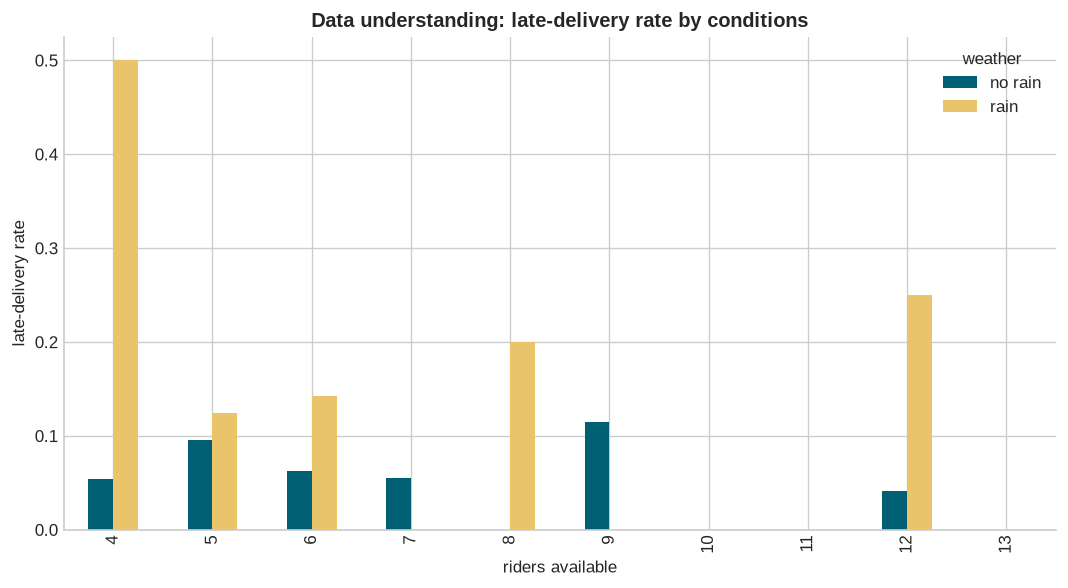

In [4]:
late_rate = data.groupby(["rain", "riders_available"])["late"].mean().unstack(0)
fig, ax = plt.subplots(figsize=(9, 5))
late_rate.plot(kind="bar", ax=ax, color=[TEAL, GOLD])
ax.set(title="Data understanding: late-delivery rate by conditions", xlabel="riders available", ylabel="late-delivery rate")
ax.legend(["no rain", "rain"], title="weather")
plt.tight_layout()

<h2 id="CRISP-DM-is-a-loop,-not-a-waterfall">CRISP-DM is a loop, not a waterfall</h2><p>Each stage produces an artefact that may send the team back to an earlier question.</p>

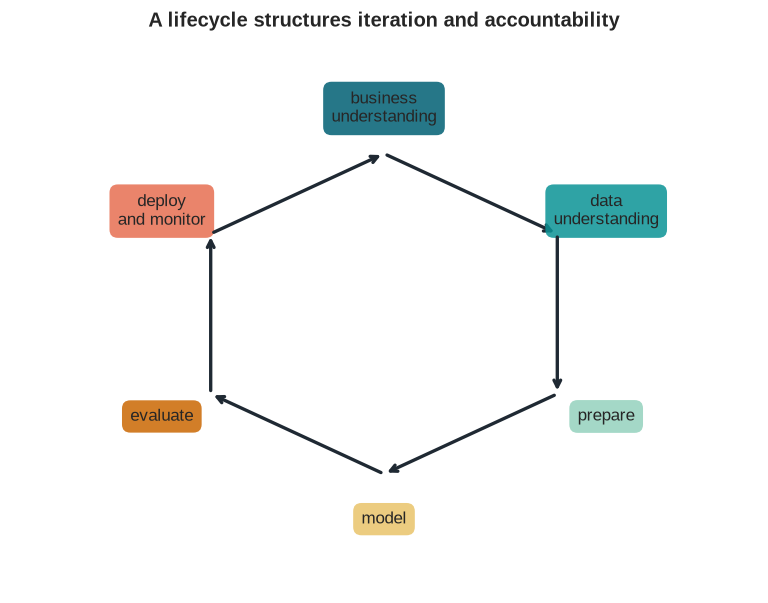

In [5]:
fig,ax=plt.subplots(figsize=(8,6)); labels=["business\nunderstanding","data\nunderstanding","prepare","model","evaluate","deploy\nand monitor"]
angles=np.linspace(np.pi/2,np.pi/2-2*np.pi,6,endpoint=False)
for i,(angle,label) in enumerate(zip(angles,labels)):
    x,y=np.cos(angle),np.sin(angle); ax.text(x,y,label,ha="center",va="center",bbox=dict(boxstyle="round,pad=.5",fc=[TEAL,"#0A9396","#94D2BD",GOLD,"#CA6702",CORAL][i],ec="none",alpha=.85))
    nx,ny=np.cos(angles[(i+1)%6]),np.sin(angles[(i+1)%6]); ax.annotate("",(nx*.78,ny*.78),(x*.78,y*.78),arrowprops=dict(arrowstyle="->",lw=2,color=INK))
ax.set(xlim=(-1.45,1.45),ylim=(-1.35,1.35),title="A lifecycle structures iteration and accountability"); ax.axis("off")
plt.show()

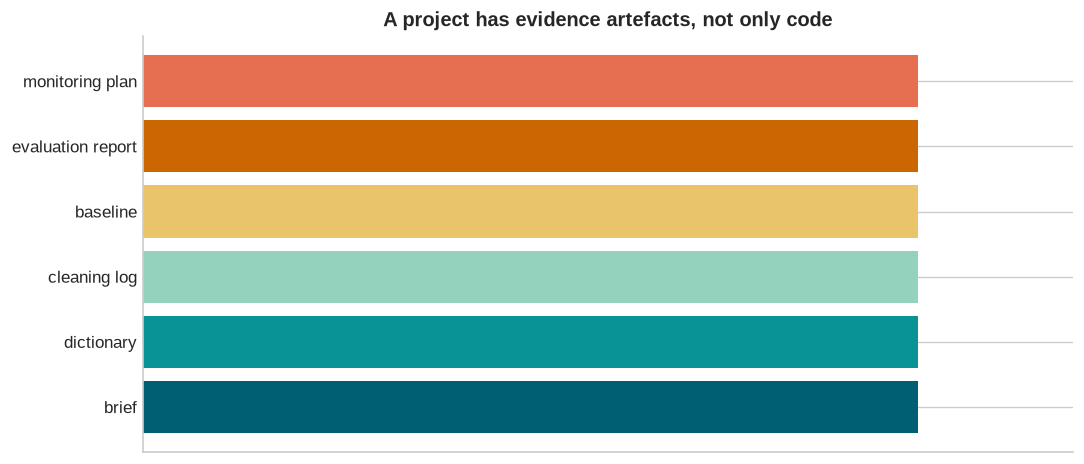

In [6]:
fig,ax=plt.subplots(figsize=(10,4.5)); stage=["brief","dictionary","cleaning log","baseline","evaluation report","monitoring plan"]
ax.barh(stage,[1]*6,color=[TEAL,"#0A9396","#94D2BD",GOLD,"#CA6702",CORAL]); ax.set(xlim=(0,1.2),xticks=[],title="A project has evidence artefacts, not only code")
plt.show()

<h2 id="OSEMN-is-a-compact-working-vocabulary">OSEMN is a compact working vocabulary</h2><p>Obtain, Scrub, Explore, Model, and iNterpret describe practical analytical work. CRISP-DM keeps the business decision, evaluation, deployment, and monitoring visible around that work.</p>

In [7]:
mapping = pd.DataFrame({
    "OSEMN activity": ["Obtain", "Scrub", "Explore", "Model", "iNterpret"],
    "example in FreshCart": ["locate order and rider records", "repair timestamps and duplicates", "compare late rate by zone and hour", "start with a simple risk rule", "recommend a pilot with limits"],
    "CRISP-DM connection": ["data understanding", "data preparation", "data understanding / evaluation", "modelling", "business understanding / evaluation / deployment"],
})
mapping

,OSEMN activity,example in FreshCart,CRISP-DM connection
0,Obtain,locate order and rider records,data understanding
1,Scrub,repair timestamps and duplicates,data preparation
2,Explore,compare late rate by zone and hour,data understanding / evaluation
3,Model,start with a simple risk rule,modelling
4,iNterpret,recommend a pilot with limits,business understanding / evaluation / deployment


<h2 id="Success-needs-two-lenses">Success needs two lenses</h2><p>A technically accurate result may still fail if it is too costly, unfair, late, or impossible to act on. Evaluate performance against both a baseline and business constraints.</p>

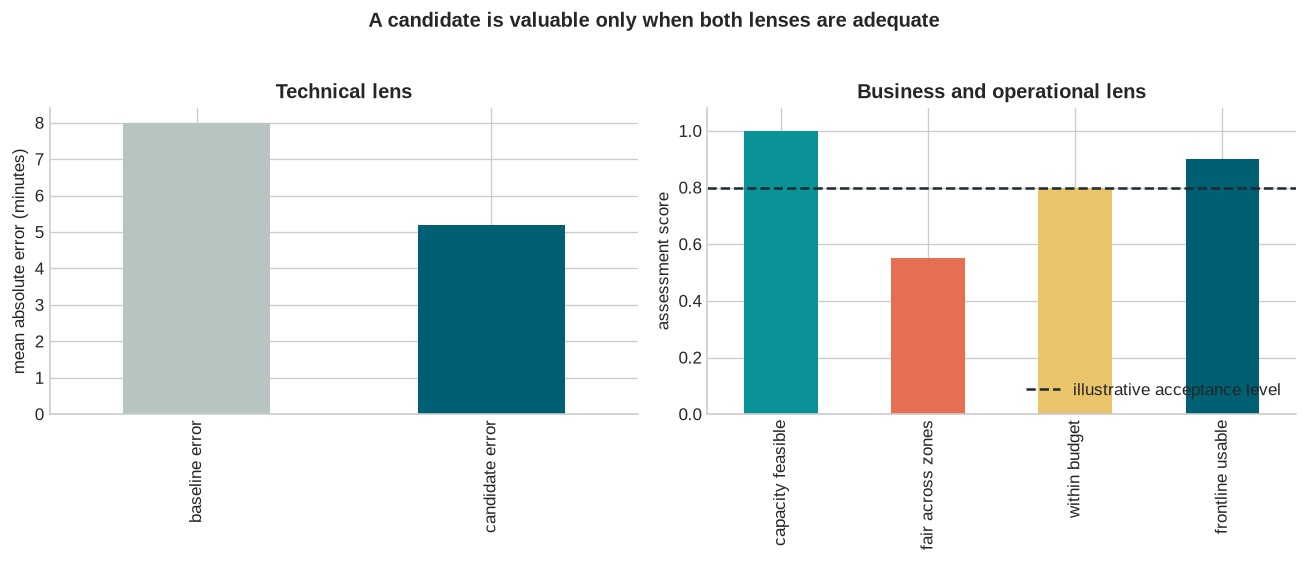

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
technical = pd.Series({"baseline error": 8.0, "candidate error": 5.2})
technical.plot(kind="bar", ax=axes[0], color=["#B8C4C2", TEAL])
axes[0].set(title="Technical lens", ylabel="mean absolute error (minutes)", xlabel="")
business = pd.Series({"capacity feasible": 1, "fair across zones": .55, "within budget": .8, "frontline usable": .9})
business.plot(kind="bar", ax=axes[1], color=[MINT, CORAL, GOLD, TEAL])
axes[1].axhline(.8, color=INK, ls="--", lw=1.5, label="illustrative acceptance level")
axes[1].set(title="Business and operational lens", ylim=(0, 1.08), ylabel="assessment score", xlabel="")
axes[1].legend(loc="lower right")
fig.suptitle("A candidate is valuable only when both lenses are adequate", weight="bold", y=1.03)
plt.tight_layout()

<h2 id="Iteration-is-evidence-of-learning,-not-failure">Iteration is evidence of learning, not failure</h2><p>A finding should send the team backward when it changes a premise: perhaps records are not comparable, the metric is poorly chosen, a simpler baseline suffices, or an action is infeasible.</p>

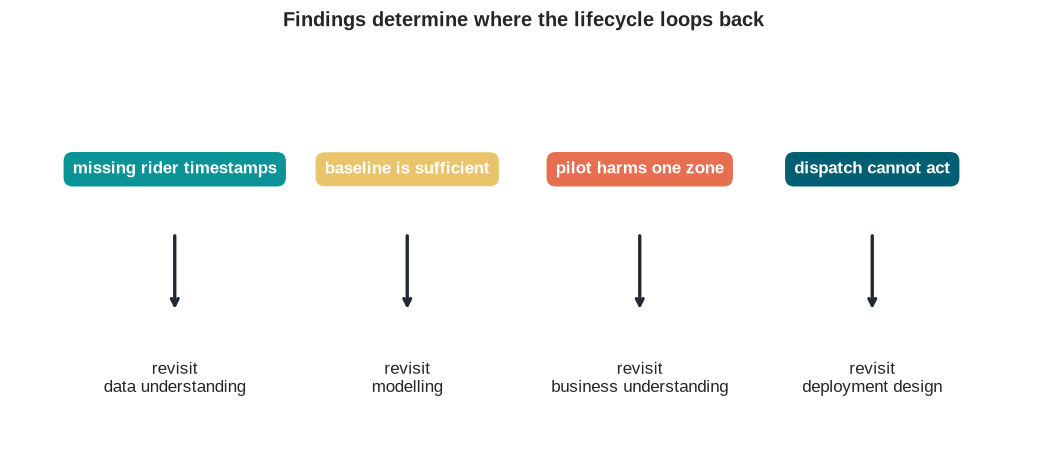

In [9]:
fig, ax = plt.subplots(figsize=(11, 4.5))
events = [
    ("missing rider timestamps", "data understanding", MINT),
    ("baseline is sufficient", "modelling", GOLD),
    ("pilot harms one zone", "business understanding", CORAL),
    ("dispatch cannot act", "deployment design", TEAL),
]
for i, (finding, return_to, colour) in enumerate(events):
    ax.text(i, .85, finding, ha="center", va="center", color="white", weight="bold", wrap=True,
            bbox=dict(boxstyle="round,pad=.55", fc=colour, ec="none"))
    ax.annotate("", (i, .42), (i, .66), arrowprops=dict(arrowstyle="->", color=INK, lw=2))
    ax.text(i, .22, f"revisit\n{return_to}", ha="center", va="center")
ax.set(xlim=(-.7, 3.7), ylim=(0, 1.25), title="Findings determine where the lifecycle loops back")
ax.axis("off")
plt.show()

<h3 id="Student-activity">Student activity</h3><p>Choose one late-delivery intervention.  Add a success metric, a guardrail, and a monitoring signal.  Identify one reason the chart does not establish that adding riders will reduce lateness.</p>

<h2 id="Applied-lifecycle-lab:-from-record-to-hold-out-evidence">Applied lifecycle lab: from record to hold-out evidence</h2><p>The diabetes study data gives a compact lifecycle example. The aim here is not a medical intervention. It is to make the lifecycle artefacts visible: a raw record, a locked test set, a fitted rule, and an error review.</p>

In [10]:
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

study = load_diabetes(as_frame=True).frame
study[["bmi", "bp", "s5", "target"]].head(8)

,bmi,bp,s5,target
0,0.061696,0.021872,0.019907,151.0
1,-0.051474,-0.026328,-0.068332,75.0
2,0.044451,-0.005670,0.002861,141.0
3,-0.011595,-0.036656,0.022688,206.0
4,-0.036385,0.021872,-0.031988,135.0
5,-0.040696,-0.019442,-0.041176,97.0
6,-0.047163,-0.015999,-0.062917,138.0
7,-0.001895,0.066629,-0.035816,63.0


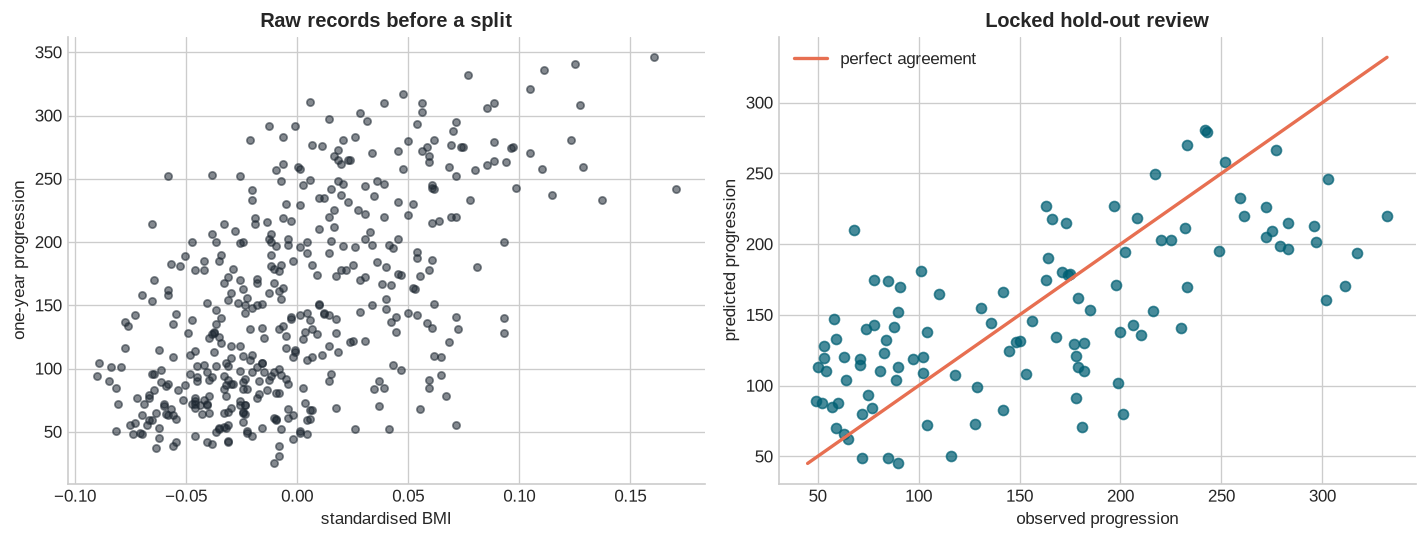

In [11]:
features = ["bmi", "bp", "s5"]
X_train, X_test, y_train, y_test = train_test_split(study[features], study.target, test_size=.25, random_state=301)
model = LinearRegression().fit(X_train, y_train)
pred = model.predict(X_test)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
axes[0].scatter(study.bmi, study.target, s=19, alpha=.55, color=INK)
axes[0].set(title="Raw records before a split", xlabel="standardised BMI", ylabel="one-year progression")
axes[1].scatter(y_test, pred, color=TEAL, alpha=.72)
limits = [min(y_test.min(), pred.min()), max(y_test.max(), pred.max())]
axes[1].plot(limits, limits, color=CORAL, lw=2, label="perfect agreement")
axes[1].set(title="Locked hold-out review", xlabel="observed progression", ylabel="predicted progression"); axes[1].legend()
plt.tight_layout()

<p>The plot on the right belongs at the evaluation stage. Reusing the training rows there would make the lifecycle look stronger than it is.</p>

### Lecture application

Identify the source audit, split manifest, validation table, held-out error report and monitoring proposal. Assign each artefact to its CRISP-DM stage and state a trigger for revisiting that stage.

## Worked project: identifying wine cultivars from measured chemistry

**Question:** can chemical measurements identify the recorded cultivar of an unseen wine sample? The UCI Wine Recognition dataset has 178 measured samples, 13 input features and three cultivar labels. A laboratory could use such a model as a screening aid. This small historical sample cannot establish performance on every producer or future vintage.

We will inspect rows and units, reserve test records, establish a majority-class baseline, select a model using training folds, inspect errors, and write a decision statement. The class label is the outcome, so it never enters the feature matrix. No download is required because scikit-learn bundles these observations.

In [12]:
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, ConfusionMatrixDisplay
project_data = load_wine(as_frame=True)
project_X, project_y = project_data.data, project_data.target
display(project_data.frame.head(8))
display(pd.DataFrame({'dtype':project_X.dtypes.astype(str), 'missing':project_X.isna().sum(),
                      'minimum':project_X.min(), 'maximum':project_X.max()}).round(3))

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0
5,14.20,1.76,2.45,15.2,112.0,3.27,3.39,0.34,1.97,6.75,1.05,2.85,1450.0,0
6,14.39,1.87,2.45,14.6,96.0,2.50,2.52,0.30,1.98,5.25,1.02,3.58,1290.0,0
7,14.06,2.15,2.61,17.6,121.0,2.60,2.51,0.31,1.25,5.05,1.06,3.58,1295.0,0


,dtype,missing,minimum,maximum
alcohol,float64,0,11.03,14.83
malic_acid,float64,0,0.74,5.80
ash,float64,0,1.36,3.23
alcalinity_of_ash,float64,0,10.60,30.00
magnesium,float64,0,70.00,162.00
total_phenols,float64,0,0.98,3.88
flavanoids,float64,0,0.34,5.08
nonflavanoid_phenols,float64,0,0.13,0.66
proanthocyanins,float64,0,0.41,3.58
color_intensity,float64,0,1.28,13.00


### Inspect the observations before choosing a model

The scatter compares two recorded features. The counts show how many examples represent each class. A two-feature view may hide separation present in the other measurements. A random stratified split assumes that these records represent the unseen samples of interest; new producers or later vintages would need a different evaluation design.

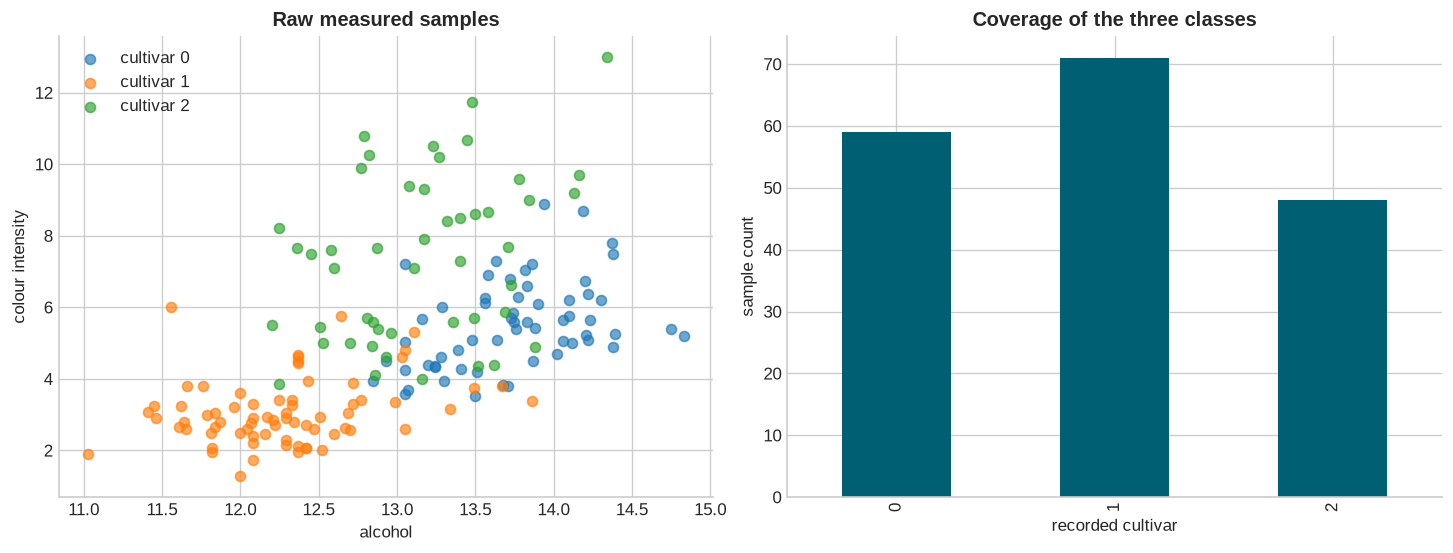

In [13]:
fig, axes = plt.subplots(1,2,figsize=(12,4.5),layout='constrained')
for label in np.unique(project_y):
    selected = project_y==label
    axes[0].scatter(project_X.loc[selected,'alcohol'],project_X.loc[selected,'color_intensity'],label=f'cultivar {label}',alpha=.65)
axes[0].set(xlabel='alcohol',ylabel='colour intensity',title='Raw measured samples'); axes[0].legend()
project_y.value_counts().sort_index().plot.bar(ax=axes[1],color='#005F73')
axes[1].set(xlabel='recorded cultivar',ylabel='sample count',title='Coverage of the three classes'); plt.show()
project_train, project_test, target_train, target_test = train_test_split(project_X,project_y,test_size=.25,stratify=project_y,random_state=301)

### Fit a baseline, then select a model using training folds

The baseline always predicts the most common training class. The learned model scales features inside each training fold and estimates logistic probabilities. The validation table selects the regularisation setting using only training data. `C` is inverse regularisation strength: a smaller value applies stronger shrinkage.

,C,validation balanced accuracy,fold SD
0,0.01,0.981,0.026
1,0.10,0.981,0.026
2,1.00,0.972,0.026
3,10.00,0.964,0.022


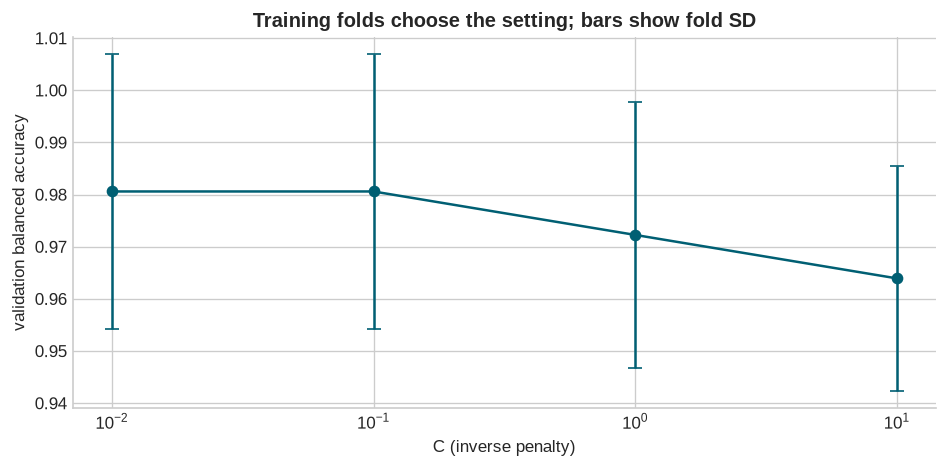

In [14]:
project_baseline = DummyClassifier(strategy='most_frequent').fit(project_train,target_train)
project_cv = StratifiedKFold(5,shuffle=True,random_state=301)
project_search = GridSearchCV(make_pipeline(StandardScaler(),LogisticRegression(max_iter=2000)),
                             {'logisticregression__C':[.01,.1,1,10]},cv=project_cv,scoring='balanced_accuracy')
project_search.fit(project_train,target_train)
cv_table = pd.DataFrame(project_search.cv_results_)[['param_logisticregression__C','mean_test_score','std_test_score']]
display(cv_table.rename(columns={'param_logisticregression__C':'C','mean_test_score':'validation balanced accuracy','std_test_score':'fold SD'}).round(3))
fig,ax=plt.subplots(figsize=(8,4))
ax.errorbar(cv_table.iloc[:,0].astype(float),cv_table.iloc[:,1],yerr=cv_table.iloc[:,2],fmt='o-',capsize=4,color='#005F73')
ax.set(xscale='log',xlabel='C (inverse penalty)',ylabel='validation balanced accuracy',title='Training folds choose the setting; bars show fold SD')
plt.tight_layout(); plt.show()

### Open the held-out set once and inspect the errors

The confusion matrix counts actual outcomes, rather than compressing every error into one score. Each row refers to the true cultivar. Off-diagonal cells show which classes the fitted model confuses. These counts are small, so a high score on this split has substantial sampling uncertainty.

,model,test accuracy,test balanced accuracy
0,majority baseline,0.4,0.333
1,selected logistic model,1.0,1.000


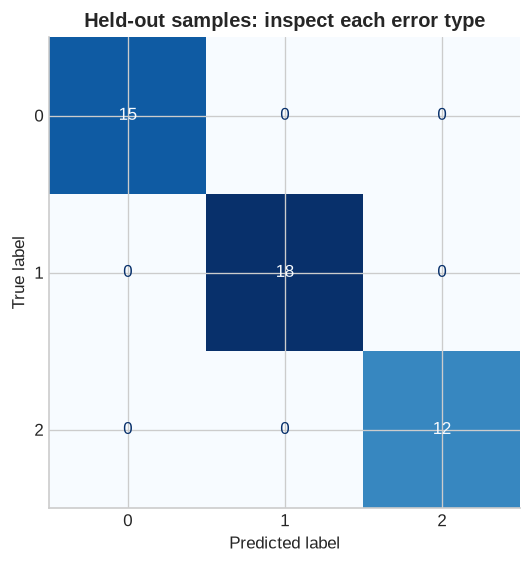

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,observed cultivar,predicted cultivar,highest probability
43,13.24,3.98,2.29,17.5,103.0,2.64,2.63,0.32,1.66,4.36,0.82,3.00,680.0,0,0,0.410
130,12.86,1.35,2.32,18.0,122.0,1.51,1.25,0.21,0.94,4.10,0.76,1.29,630.0,2,2,0.436
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,0,0.490
118,12.77,3.43,1.98,16.0,80.0,1.63,1.25,0.43,0.83,3.40,0.70,2.12,372.0,1,1,0.509
96,11.81,2.12,2.74,21.5,134.0,1.60,0.99,0.14,1.56,2.50,0.95,2.26,625.0,1,1,0.537
121,11.56,2.05,3.23,28.5,119.0,3.18,5.08,0.47,1.87,6.00,0.93,3.69,465.0,1,1,0.540
65,12.37,1.21,2.56,18.1,98.0,2.42,2.65,0.37,2.08,4.60,1.19,2.30,678.0,1,1,0.554
71,13.86,1.51,2.67,25.0,86.0,2.95,2.86,0.21,1.87,3.38,1.36,3.16,410.0,1,1,0.555


In [15]:
project_pred = project_search.predict(project_test)
baseline_pred = project_baseline.predict(project_test)
display(pd.DataFrame({'model':['majority baseline','selected logistic model'],
                      'test accuracy':[accuracy_score(target_test,baseline_pred),accuracy_score(target_test,project_pred)],
                      'test balanced accuracy':[balanced_accuracy_score(target_test,baseline_pred),balanced_accuracy_score(target_test,project_pred)]}).round(3))
fig,ax=plt.subplots(figsize=(6,4.8))
ConfusionMatrixDisplay.from_predictions(target_test,project_pred,ax=ax,cmap='Blues',colorbar=False)
ax.set_title('Held-out samples: inspect each error type'); plt.tight_layout(); plt.show()
project_review=project_test.copy()
project_review['observed cultivar']=target_test
project_review['predicted cultivar']=project_pred
project_review['highest probability']=project_search.predict_proba(project_test).max(axis=1)
display(project_review.sort_values('highest probability').head(8).round(3))

### Decision statement and next evidence

Compare the selected model with the baseline using the table above. State the held-out sample size and the errors you see. A laboratory would next validate new samples from its own measurement process and agree when a prediction requires manual review. Monitoring would track missing measurements, feature ranges, class frequencies, and verified errors. Confidence scores need calibration evidence before they can justify an automatic acceptance threshold.